In [1]:
pip install gdown

  Using cached gdown-6.1.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
Using cached gdown-6.1.0-py3-none-any.whl (19 kB)
Using cached PySocks-1.7.1-py3-none-any.whl (16 kB)

   -------------------------- ------------- 2/3 [gdown]
   ---------------------------------------- 3/3 [gdown]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
https://drive.google.com/drive/folders/1Txq9Cr3eViOhl2VzqeH_XIRD5r8SoH9Z?usp=drive_link

In [ ]:
import gdown

folder_id = "1Txq9Cr3eViOhl2VzqeH_XIRD5r8SoH9Z"
gdown.download_folder(id=folder_id, output="dataset1", quiet=False)


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    "dataset1/train",   # path to your train folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    "dataset1/test",    # path to your test folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)


ModuleNotFoundError: No module named 'tensorflow'

#### Working with Images
1. Image consists pixels
2. Pixels means intensity of light
3. Every pixels is a numerical value.
4. There 3 color channels
5.  * Red - collection all pixels of red color
    * Blue
    * Green
6. If we stack all the three channels gives us image.

In [15]:
!pip install imutils
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/44.0 MB 6.1 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/44.0 MB 6.8 MB/s eta 0:00:07
   ---- ----------------------------------- 4.5/44.0 MB 6.5 MB/s eta 0:00:07
   ----- ---------------------------------- 6.0/44.0 MB 6.2 MB/s eta 0:00:07
   ------- -------------------------------- 8.1/44.0 MB 7.1 MB/s eta 0:00:06
   -------- ------------------------------- 9.2/44.0 MB 6.5 MB/s eta 0:00:06
   --------- ------------------------------ 10.0/44.0 MB 6.1 MB/s eta 0:00:06
   ---------- ----------------------------- 11.0/44.0 MB 6.0 MB/s eta 0:00:06
   ---------- ----------------------------- 11.3/44.0 MB 5.7 MB/s eta 0:00:06
   ---------- ----------------------------- 12.1/44.0 MB 5.4 MB/s eta 0:00:06
   ----------- ---------------------------- 12.3/44.0 MB 5.0 MB/s eta 0:00:07
   -----

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Libraries to work with Image Data
from imutils import paths # imutils mean image utilities
import cv2

In [ ]:
if we want to load the image data
cv2
PIL

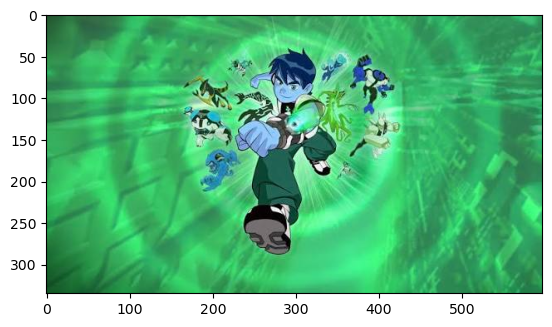

In [18]:
# loading the image and displaying image
image = cv2.imread('images.jpg')
plt.imshow(image)

In [ ]:
here x-axis is width of image
    y - axis is height of image

In [19]:
cv2.imshow(image)

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'imshow'
> Overload resolution failed:
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)


In [20]:
type(image)

numpy.ndarray

In [23]:
image.ndim
# so coloured image is 3dimension

3

In [24]:
image.shape
# (height,width,color channels)

(335, 597, 3)

In [ ]:
#### Resizing image:

In [25]:
# Let's downscale the image using new width and height
down_width = 100
down_height = 100
down_points = (down_width,down_height)
resized_down = cv2.resize(image,
                          down_points,
                          interpolation = cv2.INTER_LINEAR)

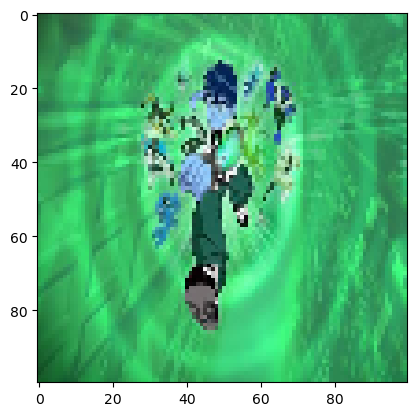

In [26]:
plt.imshow(resized_down)

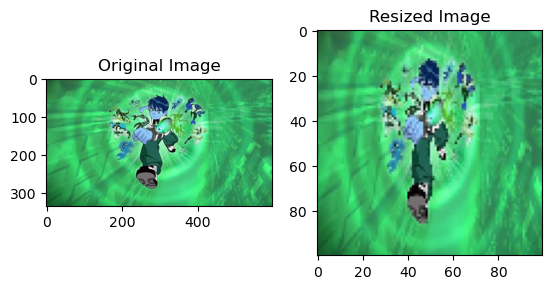

In [28]:
down_width = 100
down_height = 100
down_points = (down_width,down_height)
resized_down = cv2.resize(image,
                          down_points,
                          interpolation = cv2.INTER_LINEAR)
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(resized_down)
plt.title('Resized Image')
plt.show()

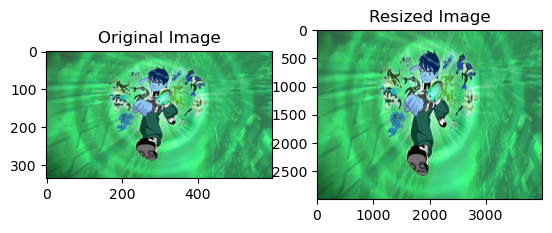

In [27]:
up_width = 4000
up_height = 3000
up_points = (up_width,up_height)
resized_up = cv2.resize(image,
                        up_points,
                        interpolation = cv2.INTER_LINEAR)
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(resized_up)
plt.title('Resized Image')
plt.show()

#### Image Rotation

In [29]:
height,width = image.shape[:2]
print(height,width)

335 597


In [30]:
center = (width/2,height/2)
print(center)

(298.5, 167.5)


In [31]:
# using cv2.getRotationMatrix2D() to get the rotation matrix
rotate_matrix = cv2.getRotationMatrix2D(center = center,
                                        angle = 45,
                                        scale = 1)
rotate_matrix

array([[  0.70710678,   0.70710678, -31.01176003],
       [ -0.70710678,   0.70710678, 260.13098834]])

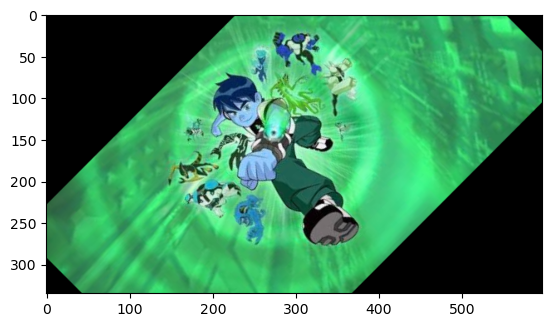

In [33]:
# rotate the image using cv2.warpAffine
rotated_image = cv2.warpAffine(src = image,
                               M = rotate_matrix,
                               dsize = (width,height))
plt.imshow(rotated_image)

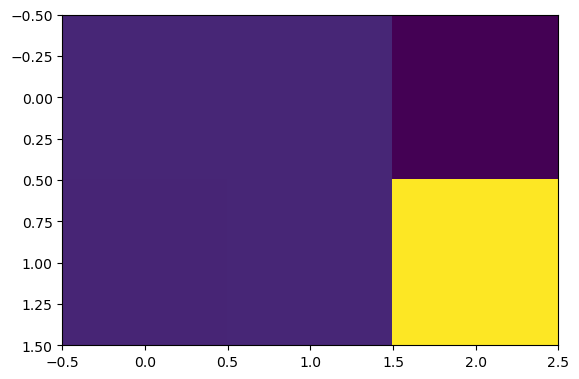

In [32]:
plt.imshow(rotate_matrix)

#### Image Cropping:

(200, 200, 3)


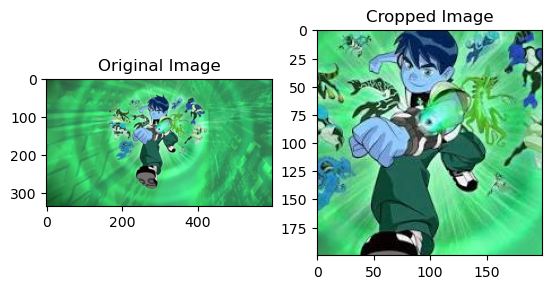

In [34]:
cropped_image = image[50:250,200:400]
print(cropped_image.shape)
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(cropped_image)
plt.title('Cropped Image')
plt.show()

#### Adding Text into Image

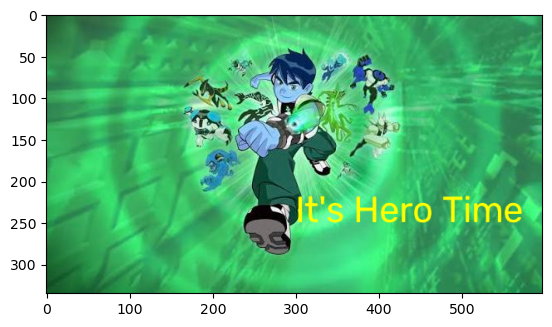

In [39]:
# make a copy of the original image
imageText = image.copy()
# let's write text you want to put on the image
text = "It's Hero Time"
# where you want to put the text
org = (300,250)
# write the text on the input image
cv2.putText(imageText,
            text,
            org,
            fontFace = cv2.FONT_HERSHEY_COMPLEX,
            fontScale = 1.5,
            color = (255,255,0))
# display output image with text
plt.imshow(imageText)

#### Changing the color code of image

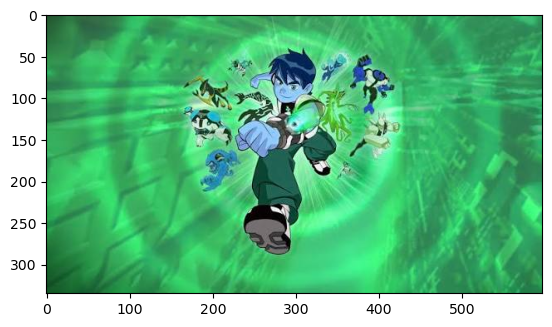

In [40]:
imageColour = image.copy()
plt.imshow(imageColour,cmap = 'Greys')

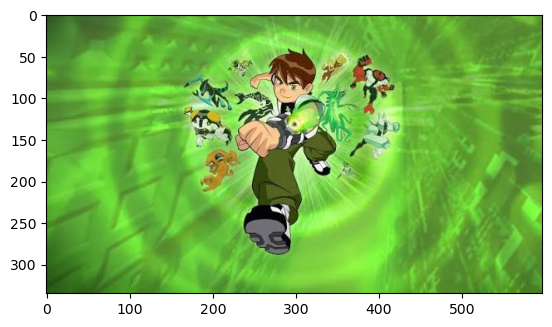

In [41]:
# BGR,HSV,YCrcB,LAB
imageBGR = cv2.cvtColor(imageColour,cv2.COLOR_RGB2BGR)
plt.imshow(imageBGR)

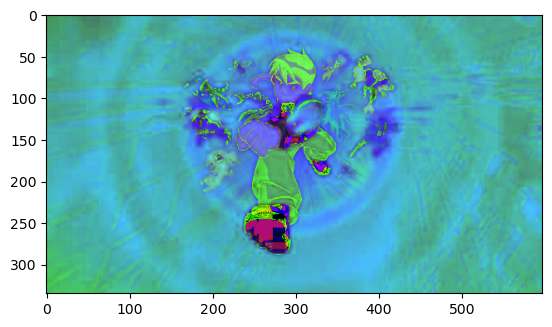

In [42]:
imageHSV = cv2.cvtColor(imageColour,cv2.COLOR_RGB2HSV)
plt.imshow(imageHSV)

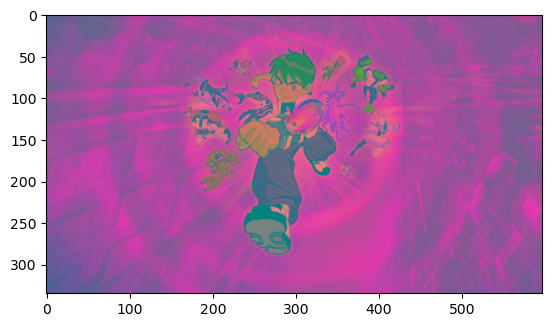

In [45]:
imageHSV = cv2.cvtColor(imageColour,cv2.COLOR_RGB2LAB)
plt.imshow(imageHSV)

#### Image Flattening

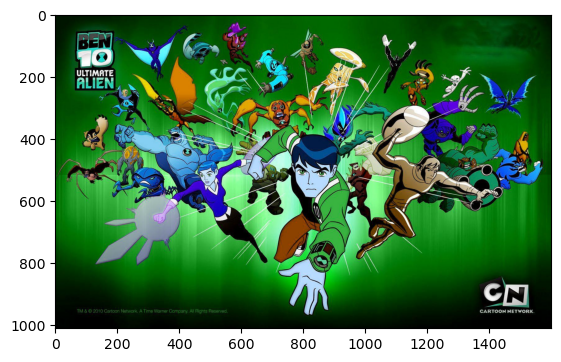

In [48]:
img = cv2.imread('image1.jpg')
plt.imshow(img)

In [52]:
# convert img to np array
img_num = np.array(img)
img_num

array([[[ 0, 21,  0],
        [ 0, 21,  0],
        [ 0, 21,  0],
        ...,
        [ 0, 19,  0],
        [ 0, 19,  0],
        [ 0, 19,  0]],

       [[ 0, 21,  0],
        [ 0, 21,  0],
        [ 0, 21,  0],
        ...,
        [ 0, 19,  0],
        [ 0, 19,  0],
        [ 0, 19,  0]],

       [[ 0, 21,  0],
        [ 0, 21,  0],
        [ 0, 21,  0],
        ...,
        [ 0, 19,  0],
        [ 0, 19,  0],
        [ 0, 19,  0]],

       ...,

       [[ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(1011, 1600, 3), dtype=uint8)

In [50]:
img_num.shape

(1011, 1600, 3)

In [51]:
img_num.ndim

3

In [53]:
img_flat = img_num.flatten()

In [54]:
img_flat.shape

(4852800,)

In [ ]:
here 4852800 = (height*width*

In [55]:
img_flat.ndim

1

1. when we apply flatten it gives the data in one dimensional 
2. one image can give one row
3. if we want more rows we want more images

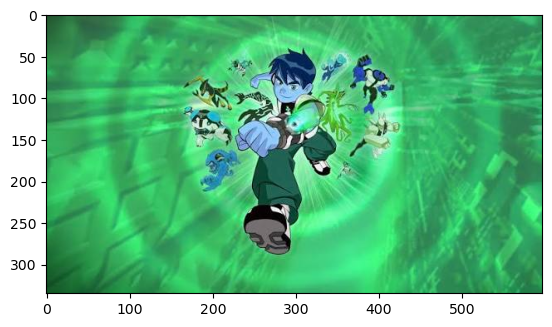

In [56]:
img2 = cv2.imread('images.jpg')
plt.imshow(img2)

In [59]:
# converting other image into flat
img2_num = np.array(img2)
img2_flat = img2_num.flatten()
img2_flat.size

599985

In [60]:
# convert above 1D array into Data Frame
d = pd.DataFrame(img_flat)
d

,0
0,0
1,21
2,0
3,0
4,21
...,...
4852795,0
4852796,0
4852797,0
4852798,0


#### Handling Multiple images in a folders